### 安裝套件

In [1]:
import shap
import itertools
import numpy as np
import pandas as pd 
import xgboost as xgb
import lightgbm as lgb
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.model_selection import GroupKFold
from statsmodels.stats.multitest import multipletests

d:\python_test2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 匯入資料

In [2]:
file_path='./WB_Machine_Error_Event_0722_0728.xlsx'
df=pd.read_excel(file_path)
#print(df.head())
print(df.shape)

(35607, 14)


### 查看欄位名稱

In [3]:
df.columns

Index(['step_id', 'lot_id', 'equip_type', 'equip_id', 'device_name',
       'recipe_id', 'in_qty', 'ng_qty', 'start_time', 'end_time', 'location',
       'floor', 'eventmessage', 'eventcount'],
      dtype='object')

### eventcount有空值

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35607 entries, 0 to 35606
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   step_id       35607 non-null  object        
 1   lot_id        35607 non-null  object        
 2   equip_type    35607 non-null  object        
 3   equip_id      35607 non-null  object        
 4   device_name   35607 non-null  object        
 5   recipe_id     35607 non-null  object        
 6   in_qty        35607 non-null  int64         
 7   ng_qty        35607 non-null  float64       
 8   start_time    35607 non-null  datetime64[ns]
 9   end_time      35607 non-null  datetime64[ns]
 10  location      35607 non-null  object        
 11  floor         35607 non-null  object        
 12  eventmessage  31510 non-null  object        
 13  eventcount    31510 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(9)
memory usage: 3.8+ MB


In [5]:
df.loc[df['eventmessage'].isna(),"eventcount"].value_counts(dropna=False)

eventcount
NaN    4097
Name: count, dtype: int64

In [6]:
#df.describe()

### 將eventcount空值的地方已0呈現，代表發生次數為0

In [7]:
df['eventcount']=df['eventcount'].fillna(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35607 entries, 0 to 35606
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   step_id       35607 non-null  object        
 1   lot_id        35607 non-null  object        
 2   equip_type    35607 non-null  object        
 3   equip_id      35607 non-null  object        
 4   device_name   35607 non-null  object        
 5   recipe_id     35607 non-null  object        
 6   in_qty        35607 non-null  int64         
 7   ng_qty        35607 non-null  float64       
 8   start_time    35607 non-null  datetime64[ns]
 9   end_time      35607 non-null  datetime64[ns]
 10  location      35607 non-null  object        
 11  floor         35607 non-null  object        
 12  eventmessage  31510 non-null  object        
 13  eventcount    35607 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(9)
memory usage: 3.8+ MB


### 新增欄位:製造時間、不良率

In [9]:
#製造時間
df["duration_min"] = (df["end_time"] - df["start_time"]).dt.total_seconds() / 60 #除以60轉成分鐘
#不良率
# df["ng_rate"] = df["ng_qty"].div(df["in_qty"]).where(df["in_qty"] > 0)


In [10]:
# pd.set_option("display.max_rows",None)

In [11]:
# df['recipe_id'].value_counts()

### 觀察發生最多次的錯誤事件
EX:在錯誤事件為'PDT-UNEXPECTED-SHTL'之下，總共發生了13764的錯誤次數

In [12]:
event_summary = (
            df.groupby(["eventmessage"], as_index=False)
            .agg(
            event_count=("eventcount", "sum"),
            ))
#event_summary["ng_rate"] = (event_summary["ng_qty"] / event_summary["in_qty"])
event_summary = event_summary.sort_values("event_count",ascending=False)
print(event_summary.head())
print(event_summary.shape)

           eventmessage  event_count
28  PDT-UNEXPECTED-SHTL      13764.0
27  PDT-UNEXPECTED-NSOP      10216.0
20    PBI-WIRE-STOP-ERR       7433.0
26  PDT-UNEXPECTED-NSOL       5065.0
22         PDT-EFO-OPEN       3931.0
(39, 2)


In [13]:
# event_summary

In [14]:
# df.groupby(["step_id","lot_id","equip_id","device_name"], as_index=False).agg(event_count=("eventcount", "sum")).shape

In [15]:
# df.groupby(["eventmessage","step_id","lot_id","equip_id","device_name"], as_index=False).agg(event_count=("eventcount", "sum")).shape

In [16]:
# event_summary = (
#             df.groupby(["eventmessage","step_id","lot_id","equip_id","device_name"], as_index=False)
#             .agg(
#             event_count=("eventcount", "sum"),
#             ng_qty=("ng_qty", "max"),
#             in_qty=("in_qty", "max")
#             ))
# event_summary["ng_rate"] = (event_summary["ng_qty"] / event_summary["in_qty"])
# event_summary = event_summary.sort_values("event_count",ascending=False)
# print(event_summary.head())
# print(event_summary.shape)

In [17]:
# df[(df["eventmessage"]=='EFU open error') & (df['equip_id']=='WB3504')]

## 錯誤事件 Pareto 分析

Pareto 分析的目的，是找出少數幾種主要錯誤是否占了大部分事件。
分析結果:前三種錯誤就佔了43.35%，分別為PDT-UNEXPECTED-SHTL、PDT-UNEXPECTED-NSOP、PBI-WIRE-STOP-ERR。

In [18]:
event_pareto = (
df.groupby("eventmessage")["eventcount"]
.sum()
.sort_values(ascending=False)
.reset_index()
)
event_pareto["percentage"] = (event_pareto["eventcount"] /event_pareto["eventcount"].sum())
event_pareto["cumulative_percentage"] = (event_pareto["percentage"].cumsum())
print(event_pareto.head(20))
main_events=event_pareto.loc[:2,['eventmessage']]['eventmessage'].tolist()
print(main_events)
print(event_pareto.shape)

                     eventmessage  eventcount  percentage  \
0             PDT-UNEXPECTED-SHTL     13764.0    0.189940   
1             PDT-UNEXPECTED-NSOP     10216.0    0.140978   
2               PBI-WIRE-STOP-ERR      7433.0    0.102574   
3             PDT-UNEXPECTED-NSOL      5065.0    0.069896   
4                    PDT-EFO-OPEN      3931.0    0.054247   
5             Ball position error      3921.0    0.054109   
6                   No tail error      3680.0    0.050783   
7           Pad nonsticking error      3666.0    0.050590   
8              PDT-WIREFEED-ERROR      3508.0    0.048410   
9          Lead nonsticking error      3383.0    0.046685   
10                 EFU open error      3048.0    0.042062   
11                  EH-PDT-SMBALL      1579.0    0.021790   
12              Spool empty error      1577.0    0.021762   
13             No bump tail error      1556.0    0.021472   
14                Ball size error      1400.0    0.019320   
15             AUTO-VLL-

In [19]:
# event_pareto.head(10)

畫 Pareto 圖

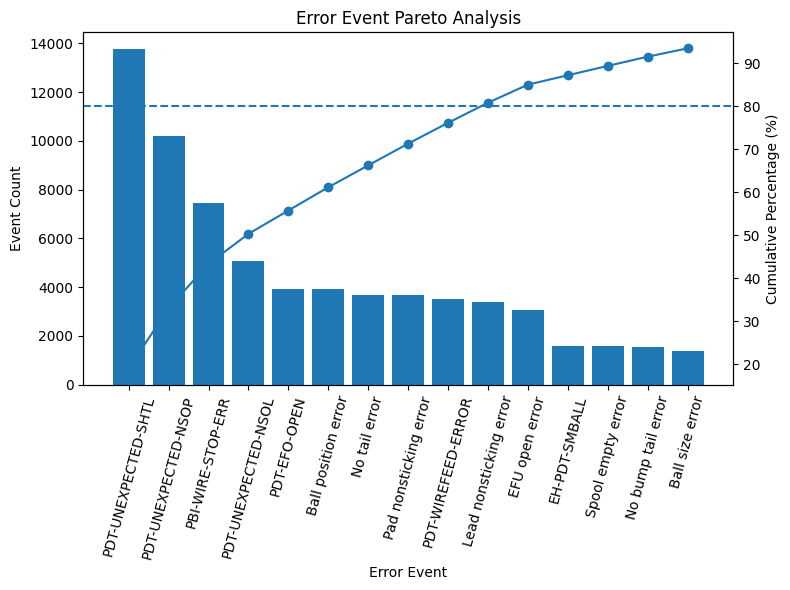

In [20]:
top_n = 15
plot_data = event_pareto.head(top_n)
#plot_data = event_pareto
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.bar(
plot_data["eventmessage"],
plot_data["eventcount"]
)
ax1.set_xlabel("Error Event")
ax1.set_ylabel("Event Count")
ax1.tick_params(axis="x", rotation=75)
ax2 = ax1.twinx()
ax2.plot(
plot_data["eventmessage"],
plot_data["cumulative_percentage"] * 100,
marker="o"
)
ax2.axhline(80, linestyle="--")
ax2.set_ylabel("Cumulative Percentage (%)")
plt.title("Error Event Pareto Analysis")
plt.tight_layout()
plt.show()

### 在這三個最常發生錯誤的事件下，分別哪些機台最常發生錯誤

In [21]:
event_machine = (
    df.loc[df['eventmessage'].isin(main_events)].groupby(["eventmessage", "equip_id"], as_index=False)
      .agg(
          event_count=("eventcount", "sum")
         # lot_count=("lot_id", "nunique"),
         # ng_qty=("ng_qty", "sum"),
         # in_qty=("in_qty", "sum")
      )
)

# event_machine["ng_rate"] = (
#     event_machine["ng_qty"] / event_machine["in_qty"]
# )
# #重點不要只看錯誤總數，因為產量高的機台錯誤數通常也會比較高。
# #更公平的比較方式是建立「每千投入量錯誤次數」。
# event_machine["events_per_1000"] = (event_machine["event_count"] /event_machine["in_qty"] * 1000)

event_machine = event_machine.sort_values(
    ["eventmessage", "event_count"],
    ascending=[True, False]
)
print(event_machine.groupby("eventmessage", group_keys=False)#不把分組eventage加進index
    .head(3))
print(event_machine.shape)

             eventmessage equip_id  event_count
454     PBI-WIRE-STOP-ERR  WBK3150         81.0
811     PBI-WIRE-STOP-ERR  WBR2250         67.0
779     PBI-WIRE-STOP-ERR  WBR2205         56.0
1289  PDT-UNEXPECTED-NSOP  WBC6034         74.0
1390  PDT-UNEXPECTED-NSOP  WBC7035         60.0
2152  PDT-UNEXPECTED-NSOP  WBR2259         54.0
2828  PDT-UNEXPECTED-SHTL  WBC7120         98.0
2899  PDT-UNEXPECTED-SHTL  WBC7236         80.0
2812  PDT-UNEXPECTED-SHTL  WBC7035         64.0
(3821, 3)


In [22]:
# check = (
#     df.groupby("equip_id")["device_name"]
#       .nunique()
#       .reset_index(name="device_count")
# )

# print(check)

### 分析錯誤事件與產品間的關係

In [23]:
recipe_summary = (
df.loc[df['eventmessage'].isin(main_events)].groupby(['eventmessage',"recipe_id"], as_index=False)
.agg(
event_count=("eventcount", "sum")
# machine_count=("equip_id", "nunique"),
# lot_count=("lot_id", "nunique"),
# in_qty=("in_qty", "sum"),
# ng_qty=("ng_qty", "sum")
)
)
# device_summary["ng_rate"] = (device_summary["ng_qty"] /device_summary["in_qty"])
# device_summary["events_per_1000"] = (device_summary["event_count"] /device_summary["in_qty"] * 1000)
recipe_summary = recipe_summary.sort_values(["eventmessage","event_count"],ascending=[True,False])
print(recipe_summary.groupby("eventmessage", group_keys=False).head(3))

            eventmessage              recipe_id  event_count
96     PBI-WIRE-STOP-ERR  SMIM96HGG404-00-AF-00        568.0
48     PBI-WIRE-STOP-ERR  SMIM157GG407-01-AF-00        402.0
101    PBI-WIRE-STOP-ERR  SSOR89000005-00-CU-00        293.0
255  PDT-UNEXPECTED-NSOP  STSL15BGK310-00-EX-00        621.0
274  PDT-UNEXPECTED-NSOP  STSM52DGK308-00-AG-00        353.0
242  PDT-UNEXPECTED-NSOP  SMIM784G7303-00-BG-00        330.0
414  PDT-UNEXPECTED-SHTL  SMIM96HGG404-00-AF-00        738.0
439  PDT-UNEXPECTED-SHTL  STSM52DGK308-00-AG-00        519.0
338  PDT-UNEXPECTED-SHTL  SMIF004G7401-01-PO-00        477.0


在錯誤事件為'PBI-WIRE-STOP-ERR'之下，機型是WBK3150具有最高的event_count。
在錯誤事件為'PBI-WIRE-STOP-ERR'之下，產品是Y5BN8ZA64PTP31245-STK-HVM-CIP 具有最高的event_count。
現在想知道的是，WBK3150是因為Y5BN8ZA64PTP31245-STK-HVM-CIP 才具有最高的events_per_1000，還是不管生產甚麼產品都容易發生?

In [24]:
event = "PDT-UNEXPECTED-SHTL"

# --------------------------------------------------
# 1. 分子：指定錯誤事件的總發生次數
# --------------------------------------------------
event_count_summary = (
    df[df["eventmessage"] == event]
    .groupby(
        ["equip_id", "recipe_id"],
        as_index=False,
        dropna=False
    )
    .agg(
        event_count=("eventcount", "sum")
        # affected_lot_count=("lot_id", "nunique")
    )
)
print(event_count_summary.shape)
# --------------------------------------------------
# 2. 分母：所有生產紀錄的實際處理量
# 每個 Step × Lot × Machine × Device x Recipe 的 in_qty 只取一次
# --------------------------------------------------
production_run_summary = (
    df.groupby(
        [
            "step_id",
            "lot_id",
            "equip_type",
            "equip_id",
            "recipe_id",
            "device_name"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        in_qty=("in_qty", "max")
    )
)#計算每次生產的輸入數量(可觀察excel第一筆跟第二筆驗證)

# --------------------------------------------------
# 3. 彙總成 Machine × Recipe
# --------------------------------------------------
production_summary = (
    production_run_summary
    .groupby(
        ["equip_id", "recipe_id"],
        as_index=False,
        dropna=False
    )
    .agg(
        in_qty=("in_qty", "sum")
        # total_lot_count=("lot_id", "nunique")
    )
)

# --------------------------------------------------
# 4. 合併分子和分母
# --------------------------------------------------
machine_recipe_summary = production_summary.merge(
    event_count_summary,
    on=["equip_id", "recipe_id"],
    how="left"
)

# machine_recipe_summary["event_count"] = (
#     machine_recipe_summary["event_count"]
#     .fillna(0)
# )

# machine_recipe_summary["affected_lot_count"] = (
#     machine_recipe_summary["affected_lot_count"]
#     .fillna(0)
#     .astype(int)
# )

# --------------------------------------------------
# 5. 每千投入錯誤次數
# --------------------------------------------------
machine_recipe_summary["event_per_1000"] = np.where(
    machine_recipe_summary["in_qty"] > 0,
    machine_recipe_summary["event_count"]
    / machine_recipe_summary["in_qty"]
    * 1000,
    np.nan
)

# --------------------------------------------------
# 6. Lot 發生率
# --------------------------------------------------
# machine_recipe_summary["affected_lot_rate"] = np.where(
#     machine_recipe_summary["total_lot_count"] > 0,
#     machine_recipe_summary["affected_lot_count"]
#     / machine_recipe_summary["total_lot_count"],
#     np.nan
# )

# --------------------------------------------------
# 7. 篩選掉太低的in_qty數量
# --------------------------------------------------
minimum_inqty_count=machine_recipe_summary['in_qty'].quantile(0.25)
machine_recipe_summary=machine_recipe_summary[machine_recipe_summary['in_qty']>=minimum_inqty_count]
# --------------------------------------------------
# 8. 排序
# --------------------------------------------------
machine_recipe_summary = (
    machine_recipe_summary
    .sort_values(
        ["event_per_1000", "event_count"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

machine_recipe_summary.head(20)

(1680, 3)


,equip_id,recipe_id,in_qty,event_count,event_per_1000
0,WBL0025,STSL15DGK305-01-EX-02,4407,59.0,13.387792
1,WBC7236,SITM46XGX324-00-KR-01,7634,80.0,10.479434
2,WBL5203,STSM52DGK308-00-AG-00,3866,40.0,10.346611
3,WBC7120,FMIS665ML411-00-TP-00,10351,98.0,9.467684
4,WBR2036,SITM46XGX328-00-KR-04,7008,61.0,8.704338
5,WBL0026,STSL15DGK305-01-EX-02,5552,39.0,7.024496
6,WB2509,SMIM416GG410-00-PO-00,8196,56.0,6.832601
7,WBR6226,SMIM56HDG471-00-PO-02,8624,54.0,6.261596
8,WBL0145,STSM52DGK308-00-AG-00,4694,29.0,6.178100
9,WBC7215,SITM32DGX325-00-KR-00,5351,31.0,5.793310


In [25]:
# production_run_summary[production_run_summary['equip_id']=='WB2075']      

### PBI-WIRE-STOP-ERR的錯誤事件分析


In [26]:
event = "PBI-WIRE-STOP-ERR"

# --------------------------------------------------
# 1. 分子：指定錯誤事件的總發生次數
# --------------------------------------------------
event_count_summary = (
    df[df["eventmessage"] == event]
    .groupby(
        ["equip_id", "recipe_id"],
        as_index=False,
        dropna=False
    )
    .agg(
        event_count=("eventcount", "sum")
        # affected_lot_count=("lot_id", "nunique")
    )
)
print(event_count_summary.shape)
# --------------------------------------------------
# 2. 分母：所有生產紀錄的實際處理量
# 每個 Step × Lot × Machine × Device x Recipe 的 in_qty 只取一次
# --------------------------------------------------
production_run_summary = (
    df.groupby(
        [
            "step_id",
            "lot_id",
            "equip_id",
            "recipe_id",
            "device_name"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        in_qty=("in_qty", "max")
    )
)#計算每次生產的輸入數量(可觀察excel第一筆跟第二筆驗證)

# --------------------------------------------------
# 3. 彙總成 Machine × Recipe
# --------------------------------------------------
production_summary = (
    production_run_summary
    .groupby(
        ["equip_id", "recipe_id"],
        as_index=False,
        dropna=False
    )
    .agg(
        in_qty=("in_qty", "sum")
        # total_lot_count=("lot_id", "nunique")
    )
)

# --------------------------------------------------
# 4. 合併分子和分母
# --------------------------------------------------
machine_recipe_summary = production_summary.merge(
    event_count_summary,
    on=["equip_id", "recipe_id"],
    how="left"
)

# machine_recipe_summary["event_count"] = (
#     machine_recipe_summary["event_count"]
#     .fillna(0)
# )

# machine_recipe_summary["affected_lot_count"] = (
#     machine_recipe_summary["affected_lot_count"]
#     .fillna(0)
#     .astype(int)
# )

# --------------------------------------------------
# 5. 每千投入錯誤次數
# --------------------------------------------------
machine_recipe_summary["event_per_1000"] = np.where(
    machine_recipe_summary["in_qty"] > 0,
    machine_recipe_summary["event_count"]
    / machine_recipe_summary["in_qty"]
    * 1000,
    np.nan
)

# --------------------------------------------------
# 6. Lot 發生率
# --------------------------------------------------
# machine_recipe_summary["affected_lot_rate"] = np.where(
#     machine_recipe_summary["total_lot_count"] > 0,
#     machine_recipe_summary["affected_lot_count"]
#     / machine_recipe_summary["total_lot_count"],
#     np.nan
# )

# --------------------------------------------------
# 7. 篩選掉太低的in_qty數量
# --------------------------------------------------
minimum_inqty_count=machine_recipe_summary['in_qty'].quantile(0.25)
machine_recipe_summary=machine_recipe_summary[machine_recipe_summary['in_qty']>=minimum_inqty_count]
# --------------------------------------------------
# 8. 排序
# --------------------------------------------------
machine_recipe_summary = (
    machine_recipe_summary
    .sort_values(
        ["event_per_1000", "event_count"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

machine_recipe_summary.head(20)

(1130, 3)


,equip_id,recipe_id,in_qty,event_count,event_per_1000
0,WBR2205,SITM32DGX318-01-KR-00,6737,56.0,8.312305
1,WBL5203,STSM52DGK308-00-AG-00,3866,31.0,8.018624
2,WBL5151,STSM52DGK308-00-AG-00,3760,30.0,7.978723
3,WBL0145,STSM52DGK308-00-AG-00,4694,37.0,7.882403
4,WBC7200,SSOR89000005-00-CU-00,6353,50.0,7.870297
5,WBC7193,SSOR89000005-00-CU-00,4501,31.0,6.887358
6,WBR2276,SITM32DGX318-01-KR-00,5244,35.0,6.674294
7,WBR9073,SMIM156GG404-00-AF-01,7234,43.0,5.944153
8,WBC7204,SSOR89000005-00-CU-00,5365,31.0,5.778192
9,WBR2109,SMIM156GG401-00-PO-01,7300,38.0,5.205479


### PDT-UNEXPECTED-NSOP的錯誤事件分析

In [27]:
event = "PDT-UNEXPECTED-NSOP"

# --------------------------------------------------
# 1. 分子：指定錯誤事件的總發生次數
# --------------------------------------------------
event_count_summary = (
    df[df["eventmessage"] == event]
    .groupby(
        ["equip_id", "recipe_id"],
        as_index=False,
        dropna=False
    )
    .agg(
        event_count=("eventcount", "sum")
        # affected_lot_count=("lot_id", "nunique")
    )
)
print(event_count_summary.shape)
# --------------------------------------------------
# 2. 分母：所有生產紀錄的實際處理量
# 每個 Step × Lot × Machine × Device x Recipe 的 in_qty 只取一次
# --------------------------------------------------
production_run_summary = (
    df.groupby(
        [
            "step_id",
            "lot_id",
            "equip_type",
            "equip_id",
            "recipe_id",
            "device_name"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        in_qty=("in_qty", "max")
    )
)#計算每次生產的輸入數量(可觀察excel第一筆跟第二筆驗證)

# --------------------------------------------------
# 3. 彙總成 Machine × Recipe
# --------------------------------------------------
production_summary = (
    production_run_summary
    .groupby(
        ["equip_id", "recipe_id"],
        as_index=False,
        dropna=False
    )
    .agg(
        in_qty=("in_qty", "sum")
        # total_lot_count=("lot_id", "nunique")
    )
)

# --------------------------------------------------
# 4. 合併分子和分母
# --------------------------------------------------
machine_recipe_summary = production_summary.merge(
    event_count_summary,
    on=["equip_id", "recipe_id"],
    how="left"
)

# machine_recipe_summary["event_count"] = (
#     machine_recipe_summary["event_count"]
#     .fillna(0)
# )

# machine_recipe_summary["affected_lot_count"] = (
#     machine_recipe_summary["affected_lot_count"]
#     .fillna(0)
#     .astype(int)
# )

# --------------------------------------------------
# 5. 每千投入錯誤次數
# --------------------------------------------------
machine_recipe_summary["event_per_1000"] = np.where(
    machine_recipe_summary["in_qty"] > 0,
    machine_recipe_summary["event_count"]
    / machine_recipe_summary["in_qty"]
    * 1000,
    np.nan
)

# --------------------------------------------------
# 6. Lot 發生率
# --------------------------------------------------
# machine_recipe_summary["affected_lot_rate"] = np.where(
#     machine_recipe_summary["total_lot_count"] > 0,
#     machine_recipe_summary["affected_lot_count"]
#     / machine_recipe_summary["total_lot_count"],
#     np.nan
# )

# --------------------------------------------------
# 7. 篩選掉太低的in_qty數量
# --------------------------------------------------
minimum_inqty_count=machine_recipe_summary['in_qty'].quantile(0.25)
machine_recipe_summary=machine_recipe_summary[machine_recipe_summary['in_qty']>=minimum_inqty_count]
# --------------------------------------------------
# 8. 排序
# --------------------------------------------------
machine_recipe_summary = (
    machine_recipe_summary
    .sort_values(
        ["event_per_1000", "event_count"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

machine_recipe_summary.head(20)

(1647, 3)


,equip_id,recipe_id,in_qty,event_count,event_per_1000
0,WBL0025,STSL15BGK310-00-EX-00,4601,42.0,9.128450
1,WBR2096,STSM54DGK306-00-BG-01,4281,39.0,9.110021
2,WBC7121,SITM32DGX325-00-KR-00,4471,32.0,7.157236
3,WBR1022,SMIM54EGG303-01-KF-01,4080,25.0,6.127451
4,WBR2069,STSM535GG332-00-EM-00,5820,35.0,6.013746
5,WBR2162,SITM46XGX328-00-KR-04,6920,39.0,5.635838
6,WBR1024,SMIM54EGG303-01-KF-01,3792,21.0,5.537975
7,WBR2107,SMIM417GG402-00-PO-02,4467,24.0,5.372733
8,WBR0004,SMIM54EGG303-01-KF-03,5289,28.0,5.294006
9,WBC7289,SITM46XGX324-00-KR-01,7613,40.0,5.254170


In [28]:
# df.loc[(df['equip_id']=='WBL0025') & (df['device_name']=='66BJY9T1C28LFAS-N3841-3M')&(df['eventmessage']=='PDT-UNEXPECTED-NSOP')]

In [29]:
# df.groupby('device_name').head(1)會先按 device_name 列將資料分成不同組，然後對每一組返回前一行資料

In [30]:
# 檢查每個 device_name 對應到幾個 recipe_id（理論上應該全部=1）
print(df.groupby('device_name')['recipe_id'].nunique().value_counts())

# 反過來檢查每個 recipe_id 對應到幾個 device_name
print(df.groupby('recipe_id')['device_name'].nunique().value_counts())

recipe_id
1    376
2     24
Name: count, dtype: int64


device_name
1    223
2     54
3     20
4      7
5      1
Name: count, dtype: int64


有376款產品(device)，每款只對應到1個recipe。有24款產品(device)，各自對應到2個不同recipe。說明實際上recipe跟device不是一對一關係。

## Permutation Test under PDT-UNEXPECTED-SHTL

In [31]:
event = "PDT-UNEXPECTED-SHTL"
# event="AUTO-VLL-FIND-FAIL"
# --------------------------------------------------
# 全部 production run
# 每一列 = Step × Lot × Machine(equip) × Recipe X Device
# --------------------------------------------------
production_run = ( #計算正確的in_qty
    df.groupby(
        [
            "step_id",
            "lot_id",
            "equip_type",
            "equip_id",
            "recipe_id",
            "device_name"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        in_qty=("in_qty", "max")
    )
)

# --------------------------------------------------
# 指定錯誤事件在每個 production run 的 event count
# --------------------------------------------------
event_run = (
    df[df["eventmessage"] == event]
    .groupby(
        [
            "step_id",
            "lot_id",
            "equip_type",
            "equip_id",
            "recipe_id",
            "device_name"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        event_count=("eventcount", "sum")
    )
)
# 也可以用這段來代替上面event_run，因為在單一錯誤事件下，以"step_id","lot_id","equip_id","recipe_id", "device_name"來分組，每組只會有一筆資料
# event_run = (
#     df[df["eventmessage"] == event][["step_id",
#             "lot_id",
#             "equip_id",
#             "recipe_id",
#             "device_name","eventcount"]])
# --------------------------------------------------
# 合併
# --------------------------------------------------
run_df = production_run.merge( #run_df代表在特定錯誤事件下，以 "step_id","lot_id","equip_id","recipe_id","device_name"來分組的inqty跟eventcount
    event_run,
    on=[
        "step_id",
        "lot_id",
        "equip_type",
        "equip_id",
        "recipe_id",
        "device_name"
    ],
    how="left"
)

#沒發生指定錯誤 → event_count = 0
run_df["event_count"] = (
    run_df["event_count"]
    .fillna(0)
)
# 任何一筆生產紀錄，只要在那次生產中沒有觸發你指定的那個 eventmessage，它在 event_run 裡就根本不會出現一列，合併後 event_count 自然是 NaN——這個 NaN 的正確語義就是「這次生產沒有發生這個錯誤事件」，也就是 0 次

# # 基本清理
# run_df = run_df.dropna(
#     subset=[
#         "equip_id",
#         "recipe_id",
#         "in_qty"
#     ]
# ).copy()

# run_df = run_df[
#     run_df["in_qty"] > 0
# ].copy()

print(production_run.shape)
print(event_run.shape)
print(run_df.shape)
run_df.head(10)

(17179, 7)
(5217, 7)
(17179, 8)


,step_id,lot_id,equip_type,equip_id,recipe_id,device_name,in_qty,event_count
0,A42,260445828.00,UTC-2000S,WB3286,FTSX489GK395-01-CA-00,6F64LJG9T25TA09,96,0.0
1,A42,260630996.00,UTC-2000S,WB3286,FTSX489GK395-01-CA-00,P36NLJG9T25TA0D,386,0.0
2,A42,260707602.00,UTC-2000S,WBB002,FTSX489GK3A2-01-CA-00,PR2NLJG9T25TA0D,775,0.0
3,A42,260709506.00,UTC-3000,WB2143,FTSX489GK3A2-01-CA-00,PR2NLJG9T25TA0D,1117,0.0
4,A42,260715290.01,UTC-3000,WBB019,FTSX489GK399-01-CA-00,PF4NLJG9T25TA0D,138,0.0
5,A42,260728901.02,UTC-3000,WB5726,FTSX480GN301-00-JH-00,66K8BVG0S3HTAI0,3200,0.0
6,A42,260728901.03,UTC-3000,WB5726,FTSX480GN301-00-JH-00,66K8BVG0S3HTAI0,3200,0.0
7,A42,260728901.03,UTC-3000,WB6315,FTSX480GN301-00-JH-00,66K8BVG0S3HTAI0,3200,0.0
8,A42,260728901.04,UTC-3000,WB5726,FTSX480GN301-00-JH-00,66K8BVG0S3HTAI0,3124,0.0
9,A42,260729950.00,IConn Pro Cu Plus LA,WBL0031,STSM329GK312-00-AG-00,HCP8LJG9W25BAIM-2DIDW63,2483,0.0


In [32]:
event_run[event_run['event_count'].isna()]

,step_id,lot_id,equip_type,equip_id,recipe_id,device_name,event_count


In [33]:
run_df[run_df['event_count'].isna()]

,step_id,lot_id,equip_type,equip_id,recipe_id,device_name,in_qty,event_count


In [34]:
# df.groupby(
#         [   "eventmessage",
#             "step_id",
#             "lot_id",
#             "equip_type",
#             "equip_id",
#             "recipe_id",
#             "device_name"
#         ],
#         as_index=False,
#         dropna=False
#     ).head()

In [35]:
# df.groupby(
#         [   "eventmessage",
#             "step_id",
#             "lot_id",
#             "equip_type",
#             "equip_id",
#             "recipe_id",
#             "device_name"
#         ],
#         as_index=False,
#         dropna=False
#     ).nunique()

In [36]:
def group_rate_variation(
    data,
    group_col
):
    """
    計算各 group 的 event rate 差異程度。

    group_col:
        "equip_id" 或 "recipe_id"
    """

    group_summary = (
        data.groupby(
            group_col,
            as_index=False
        )
        .agg(
            event_count=("event_count", "sum"),
            in_qty=("in_qty", "sum")
        )
    )

    # 每千投入錯誤次數
    group_summary["event_per_1000"] = (
        group_summary["event_count"]
        / group_summary["in_qty"]
        * 1000
    )

    # 全體平均 rate
    overall_rate = (
        group_summary["event_count"].sum()
        / group_summary["in_qty"].sum()
        * 1000
    )

    # 依投入量加權的 group 差異
    statistic = np.average(
        (group_summary["event_per_1000"]- overall_rate) ** 2,
        weights=group_summary["in_qty"]
    )#statistic是在計算event_per_1000這個變數，以in_qty加權後的變異數。如果 equip_id（或 recipe_id）真的對錯誤率(event_per_1000)有影響，不同機台之間的錯誤率應該會有明顯落差 → 這個加權變異數會比較大。如果機台其實沒有影響、錯誤率只是隨機波動 → 就算硬把資料按機台分組，各組之間的差異也不會特別大 → 加權變異數會比較小。

    return statistic

In [37]:
def permutation_test_machine(
    data,
    n_permutations=5000,
    random_state=42
):
    rng = np.random.default_rng(
        random_state
    )

    # 真實資料 statistic
    observed_stat = group_rate_variation(
        data,
        "equip_id"
    )

    perm_stats = np.empty(
        n_permutations
    )

    original_machine = (
        data["equip_id"]
        .to_numpy()
    )

    for i in range(n_permutations):

        perm_data = data.copy()

        # 隨機打亂 Machine label
        perm_data["equip_id"] = rng.permutation(
            original_machine
        )

        perm_stats[i] = group_rate_variation(
            perm_data,
            "equip_id"
        )

    # permutation p-value
    p_value = (1+ np.sum(perm_stats >= observed_stat)) / (n_permutations + 1)
    #perm_stats >= observed_stat代表檢查這5000千次隨機打亂的結果，有幾次的變異數大於等於真實資料算出來的便異數
    #分子分母都加一，是因為避免Pvalue機率等於0
    return (
        observed_stat,
        perm_stats,
        p_value
    )

In [38]:
machine_observed, machine_perm, machine_p = (
    permutation_test_machine(
        # machine_recipe_summary,
        run_df,
        n_permutations=5000,
        random_state=42
    )
)

print(
    "Machine observed statistic:",
    machine_observed
)

print(
    "Machine permutation p-value:",
    machine_p
)

Machine observed statistic: 0.9641628115414597
Machine permutation p-value: 0.0001999600079984003


In [39]:
def permutation_test_recipe(
    data,
    n_permutations=5000,
    random_state=42
):
    rng = np.random.default_rng(
        random_state
    )

    observed_stat = group_rate_variation(
        data,
        "recipe_id"
    )

    perm_stats = np.empty(
        n_permutations
    )

    original_recipe = (
        data["recipe_id"]
        .to_numpy()
    )

    for i in range(n_permutations):

        perm_data = data.copy()

        # 隨機打亂 Recipe label
        perm_data["recipe_id"] = rng.permutation(
            original_recipe
        )

        perm_stats[i] = group_rate_variation(
            perm_data,
            "recipe_id"
        )

    p_value = (
        1
        + np.sum(
            perm_stats >= observed_stat
        )
    ) / (
        n_permutations + 1
    )

    return (
        observed_stat,
        perm_stats,
        p_value
    )

In [40]:
recipe_observed, recipe_perm, recipe_p = (
    permutation_test_recipe(
        # machine_recipe_summary,
        run_df,
        n_permutations=5000,
        random_state=42
    )
)

print(
    "Recipe observed statistic:",
    recipe_observed
)

print(
    "Recipe permutation p-value:",
    recipe_p
)

Recipe observed statistic: 0.6646643080679033
Recipe permutation p-value: 0.0001999600079984003


## Permutation Test under PDT-UNEXPECTED-NSOP

In [41]:
event = "PDT-UNEXPECTED-NSOP"
# event="AUTO-VLL-FIND-FAIL"

# --------------------------------------------------
# 指定錯誤事件在每個 production run 的 event count
# --------------------------------------------------
event_run = (
    df[df["eventmessage"] == event]
    .groupby(
        [
            "step_id",
            "lot_id",
            "equip_type",
            "equip_id",
            "recipe_id",
            "device_name"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        event_count=("eventcount", "sum")
    )
)
# 也可以用這段來代替上面event_run，因為在單一錯誤事件下，以"step_id","lot_id","equip_id","recipe_id", "device_name"來分組，每組只會有一筆資料
# event_run = (
#     df[df["eventmessage"] == event][["step_id",
#             "lot_id",
#             "equip_id",
#             "recipe_id",
#             "device_name","eventcount"]])
# --------------------------------------------------
# 合併
# --------------------------------------------------
run_df = production_run.merge( #run_df代表在特定錯誤事件下，以 "step_id","lot_id","equip_id","recipe_id","device_name"來分組的inqty跟eventcount
    event_run,
    on=[
        "step_id",
        "lot_id",
        "equip_type",
        "equip_id",
        "recipe_id",
        "device_name"
    ],
    how="left"
)

#沒發生指定錯誤 → event_count = 0
run_df["event_count"] = (
    run_df["event_count"]
    .fillna(0)
)
# 任何一筆生產紀錄，只要在那次生產中沒有觸發你指定的那個 eventmessage，它在 event_run 裡就根本不會出現一列，合併後 event_count 自然是 NaN——這個 NaN 的正確語義就是「這次生產沒有發生這個錯誤事件」，也就是 0 次

run_df.head()
print(production_run.shape)
print(event_run.shape)
print(run_df.shape)

(17179, 7)
(4153, 7)
(17179, 8)


In [42]:
machine_observed, machine_perm, machine_p = (
    permutation_test_machine(
        # machine_recipe_summary,
        run_df,
        n_permutations=5000,
        random_state=42
    )
)

print(
    "Machine observed statistic:",
    machine_observed
)

print(
    "Machine permutation p-value:",
    machine_p
)

Machine observed statistic: 0.47295316816006483
Machine permutation p-value: 0.0001999600079984003


In [43]:
recipe_observed, recipe_perm, recipe_p = (
    permutation_test_recipe(
        # machine_recipe_summary,
        run_df,
        n_permutations=5000,
        random_state=42
    )
)

print(
    "Recipe observed statistic:",
    recipe_observed
)

print(
    "Recipe permutation p-value:",
    recipe_p
)

Recipe observed statistic: 0.2476892384431538
Recipe permutation p-value: 0.0001999600079984003


## Permutation Test under PBI-WIRE-STOP-ERR

In [44]:
event = "PBI-WIRE-STOP-ERR"
# event="AUTO-VLL-FIND-FAIL"

# --------------------------------------------------
# 指定錯誤事件在每個 production run 的 event count
# --------------------------------------------------
event_run = (
    df[df["eventmessage"] == event]
    .groupby(
        [
            "step_id",
            "lot_id",
            "equip_type",
            "equip_id",
            "recipe_id",
            "device_name"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        event_count=("eventcount", "sum")
    )
)
# 也可以用這段來代替上面event_run，因為在單一錯誤事件下，以"step_id","lot_id","equip_id","recipe_id", "device_name"來分組，每組只會有一筆資料
# event_run = (
#     df[df["eventmessage"] == event][["step_id",
#             "lot_id",
#             "equip_id",
#             "recipe_id",
#             "device_name","eventcount"]])
# --------------------------------------------------
# 合併
# --------------------------------------------------
run_df = production_run.merge( #run_df代表在特定錯誤事件下，以 "step_id","lot_id","equip_id","recipe_id","device_name"來分組的inqty跟eventcount
    event_run,
    on=[
        "step_id",
        "lot_id",
        "equip_type",
        "equip_id",
        "recipe_id",
        "device_name"
    ],
    how="left"
)

#沒發生指定錯誤 → event_count = 0
run_df["event_count"] = (
    run_df["event_count"]
    .fillna(0)
)
# 任何一筆生產紀錄，只要在那次生產中沒有觸發你指定的那個 eventmessage，它在 event_run 裡就根本不會出現一列，合併後 event_count 自然是 NaN——這個 NaN 的正確語義就是「這次生產沒有發生這個錯誤事件」，也就是 0 次


run_df.head()
print(production_run.shape)
print(event_run.shape)
print(run_df.shape)

(17179, 7)
(2593, 7)
(17179, 8)


In [45]:
machine_observed, machine_perm, machine_p = (
    permutation_test_machine(
        # machine_recipe_summary,
        run_df,
        n_permutations=5000,
        random_state=42
    )
)

print(
    "Machine observed statistic:",
    machine_observed
)

print(
    "Machine permutation p-value:",
    machine_p
)

Machine observed statistic: 0.7397268134806287
Machine permutation p-value: 0.0001999600079984003


In [46]:
recipe_observed, recipe_perm, recipe_p = (
    permutation_test_recipe(
        # machine_recipe_summary,
        run_df,
        n_permutations=5000,
        random_state=42
    )
)

print(
    "Recipe observed statistic:",
    recipe_observed
)

print(
    "Recipe permutation p-value:",
    recipe_p
)

Recipe observed statistic: 0.5921022132881221
Recipe permutation p-value: 0.0001999600079984003


In [47]:
# # 挑一個橫跨多台機台、樣本數夠的配方，只在這個配方內部做機台檢定
# target_recipe = "STSM52DGK308-00-AG-00"  # 換成你關心的配方
# sub_recipe = run_df[run_df["recipe_id"] == target_recipe].copy()
# print(event)
# print("這個配方涵蓋的機台數:", sub_recipe["equip_id"].nunique())
# print("這個配方的總列數:", sub_recipe.shape[0])

# if sub_recipe["equip_id"].nunique() >= 3 and sub_recipe.shape[0] >= 30:
#     m_obs, m_perm, m_p = permutation_test_machine(sub_recipe, n_permutations=5000, random_state=42)
#     print(f"控制配方後，機台效應: observed={m_obs:.4f}, p={m_p:.4f}")
# else:
#     print("樣本量不足以做這個子集的檢定")

In [48]:
# # 挑一個橫跨多台機台、樣本數夠的配方，只在這個配方內部做機台檢定
# target_recipe = "SMIM54EGG303-01-KF-01"  # 換成你關心的配方
# sub_recipe = run_df[run_df["recipe_id"] == target_recipe].copy()
# print(event)
# print("這個配方涵蓋的機台數:", sub_recipe["equip_id"].nunique())
# print("這個配方的總列數:", sub_recipe.shape[0])

# if sub_recipe["equip_id"].nunique() >= 3 and sub_recipe.shape[0] >= 30:
#     m_obs, m_perm, m_p = permutation_test_machine(sub_recipe, n_permutations=5000, random_state=42)
#     print(f"控制配方後，機台效應: observed={m_obs:.4f}, p={m_p:.4f}")
# else:
#     print("樣本量不足以做這個子集的檢定")

# Machine Learning & Shap 分析

In [49]:
# 1. 抓出全部出現過的事件類型（不含 NaN）
all_events = df["eventmessage"].dropna().unique()
print(f"共 {len(all_events)} 種事件類型")

# production_run = ( #計算正確的in_qty
#     df.groupby(
#         [
#             "step_id",
#             "lot_id",
#             "equip_type",
#             "equip_id",
#             "recipe_id",
#             "device_name"
#         ],
#         as_index=False,
#         dropna=False
#     )
#     .agg(
#         in_qty=("in_qty", "max")
#     ))


# 2. 每個生產批次 × 每種事件類型 做笛卡兒積
production_run_key = production_run[["step_id","lot_id","equip_type","equip_id","recipe_id","device_name","in_qty"]].copy()
production_run_key["_key"] = 1

events_df = pd.DataFrame({"eventmessage": all_events})
events_df["_key"] = 1

panel = production_run_key.merge(events_df, on="_key").drop(columns="_key")
print("展開後列數:", panel.shape)  

# 3. 合併每個 (生產批次, 事件類型) 的實際發生次數
event_all = (
    df.groupby(
        ["step_id","lot_id","equip_type","equip_id","recipe_id","device_name","eventmessage"],
        as_index=False, dropna=False
    )
    .agg(event_count=("eventcount","sum"))
)

run_df_all = panel.merge(
    event_all,
    on=["step_id","lot_id","equip_type","equip_id","recipe_id","device_name","eventmessage"],
    how="left"
)

# 4. 沒出現在 event_all 裡 → 這個生產批次沒發生這種事件 → 0
run_df_all["event_count"] = run_df_all["event_count"].fillna(0)

print(run_df_all.shape)
print(run_df_all["event_count"].describe())
print("每種事件類型的平均發生次數:")
print(run_df_all.groupby("eventmessage")["event_count"].mean().sort_values(ascending=False).head(10))

共 39 種事件類型
展開後列數: (669981, 8)
(669981, 9)
count    669981.000000
mean          0.108160
std           0.804734
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          79.000000
Name: event_count, dtype: float64
每種事件類型的平均發生次數:
eventmessage
PDT-UNEXPECTED-SHTL       0.801211
PDT-UNEXPECTED-NSOP       0.594680
PBI-WIRE-STOP-ERR         0.432679
PDT-UNEXPECTED-NSOL       0.294837
PDT-EFO-OPEN              0.228826
Ball position error       0.228244
No tail error             0.214215
Pad nonsticking error     0.213400
PDT-WIREFEED-ERROR        0.204203
Lead nonsticking error    0.196926
Name: event_count, dtype: float64


In [50]:
# run_df_all.iloc[39:79,:]

In [51]:
from scipy.special import gammaln

def poisson_nloglik(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-12, None)
    return np.mean(
        gammaln(y_true + 1)
        + y_pred
        - y_true * np.log(y_pred)
    )

#「loss」從來就不是一個固定公式，它是「假設資料服從某個分布 → 寫出概似函數 → 取負對數 → 這就是 loss」這整套流程的產物。

Conculsion:模型平均可解釋驗證集約 23% 的變異（5 折範圍 0.17～0.28），顯著優於僅用曝光量的基準模型，確認機台、配方、事件類型等特徵具有預測力。折間表現存在一定波動（標準差 0.023），顯示模型對部分未見過的機台類推能力仍有限，這與資料本身高度稀疏（多數組合零事件）的特性相符。

In [52]:
data = run_df_all.copy()
data["step_id"] = data["step_id"].astype("category")
# data["lot_id"] = data["lot_id"].astype("category")#因為每批lot的id都是獨一無二的，所以這個變數沒啥意義
data["equip_type"] = data["equip_type"].astype("category")
data["equip_id"] = data["equip_id"].astype("category")
data["recipe_id"] = data["recipe_id"].astype("category")
data['device_name'] = data['device_name'].astype("category")
data["eventmessage"] = data["eventmessage"].astype("category")

X = data[['step_id', 'equip_type', 'equip_id', 'recipe_id','device_name', "eventmessage"]]
# X = data[["equip_id", "recipe_id", "eventmessage"]]
y = data["event_count"]
exposure = data["in_qty"].clip(lower=1)  # 防呆：避免 in_qty=0 造成 log(0)。但run_df_all['in_qty']裡其實沒有0

# 用 GroupKFold，確保同一台機台不會同時出現在訓練/驗證集
#在run_df_all 裡，同一台機台（equip_id）會出現在很多列裡——不只每種事件類型各一列，還有很多不同的生產批次。
#如果用最普通的隨機切分（例如 train_test_split），完全有可能出現「WBC7120 這台機台的某些列被分到訓練集，另一些列被分到驗證集」這種情況。
#這樣做的問題是：模型在訓練時已經看過 WBC7120 這台機台的資料、學到了它的特性（例如「這台機台整體風險偏高」），驗證的時候卻又拿同一台機台的另一批資料去測——這不是在測「模型能不能類推到新機台」，而是在測「模型記不記得住已經看過的機台」，會讓驗證分數看起來比實際能力更好（過於樂觀），沒辦法反映模型面對全新機台時的真實表現，這正是你當初設計 GroupKFold 要避免的資料外洩（leakage）問題。
gkf = GroupKFold(n_splits=5)
groups = data["equip_id"]

#groups 這個參數告訴 GroupKFold：「以 equip_id 作為分組單位」。它會把所有不重複的機台，盡量平均分成 5 份（因為 n_splits=5），然後：
	# 每一輪，挑其中 1 份機台的資料當驗證集，剩下 4 份機台的資料當訓練集。
	# 保證「同一台機台」不會同時出現在訓練集和驗證集裡。

fold_results = []#存每一折的最佳vali loss
fold_r2 = []
all_shap_records = []
all_interaction_records = []   # 存跨折的交互作用結果

feat_list = list(X.columns)
p = len(feat_list)
pairs = list(itertools.combinations(range(p), 2))#C p 取 2，變數兩兩一組

for fold, (train_idx, valid_idx) in enumerate(gkf.split(X, y, groups=groups)):
    print(f"\n=== Fold {fold} ===")
    print(f"train={len(train_idx)} 筆, valid={len(valid_idx)} 筆, "
          f"train機台數={data.iloc[train_idx]['equip_id'].nunique()}, "
          f"valid機台數={data.iloc[valid_idx]['equip_id'].nunique()}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    exp_train, exp_valid = exposure.iloc[train_idx], exposure.iloc[valid_idx]

    dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)#因為XGBOOST不直接吃pandas dataframe的資料格式，要先轉換成它自己內部的資料結構(Dmatrix)，這樣才能用底層c++高校運算
    dtrain.set_base_margin(np.log(exp_train))#把log(in_qty)設成"起始標準分數"

    dvalid = xgb.DMatrix(X_valid, label=y_valid, enable_categorical=True)
    dvalid.set_base_margin(np.log(exp_valid))

    params = {
        "objective": "count:poisson",#告訴 XGBoost，這是一個計數資料的 Poisson 迴歸問題，內部會自動套用 log(μ) = base_margin + Σf_k(x) 這個結構
        "eval_metric": "poisson-nloglik",#訓練過程中，拿什麼指標來衡量「目前模型準不準」。poisson-nloglik 就是 Poisson 負對數概似（negative log-likelihood）——數字越小代表預測跟實際越接近，這是配合 count:poisson 這個目標函數對應的標準評估指標。
        "tree_method": "hist",#"hist"：決定樹要用什麼演算法去尋找分裂點。hist 是先把數值特徵分箱、用直方圖加速搜尋分裂點，比逐一嘗試每個切點快很多，而且這是類別特徵（enable_categorical=True）能正常運作的必要條件——之前提過，類別特徵支援只有在 hist（或 gpu_hist）底下才生效。
        "max_depth": 6,#限制每一棵樹最多長 6 層。這是防止過擬合的機制之一——樹越深，越能記住訓練資料裡的細節（包括雜訊），6 是一個常見的、不會長太深的預設值。
        "min_child_weight": 20,#一個葉節點（leaf）裡至少要累積多少「hessian 權重」（在 Poisson 目標下，近似對應到樣本數的概念）才准許存在，太少就不准這樣切。這是我們之前為了防止模型在稀疏類別（例如某台機台只出現幾次）上硬切出一個只服務極少數資料的葉節點，刻意調高的正則化參數。
        "eta": 0.05,#學習率（learning rate）。每一棵新樹修正的幅度只採納 5%，不會一次修正到位。學習率小、訓練會比較穩定、比較不容易過擬合，但代價是需要更多棵樹才能收斂，這也是為什麼下面 num_boost_round 要設到 1000。
    }


    model = xgb.train(
        params, dtrain,#用上面設定的參數，在訓練集上開始長樹。
        num_boost_round=1000,#最多長 1000 棵樹（加上 eta=0.05 這種小學習率，通常需要不少棵樹才能收斂，1000 是给足夠的空間）。
        evals=[(dtrain, "train"), (dvalid, "valid")],#每長一棵樹之後，同時在訓練集和驗證集上都算一次 poisson-nloglik，方便你邊訓練邊看兩邊的表現
        early_stopping_rounds=30,#如果連續 30 棵樹，驗證集的表現都沒有再進步（valid-poisson-nloglik 沒有創新低），就提前停止訓練，不用真的長滿 1000 棵——這是防止過擬合的另一個機制：訓練集的 loss 通常會一直下降（模型持續在記憶訓練資料的細節），但驗證集的 loss 到某個點之後就會停滯甚至回升，這時候繼續長樹只會讓模型在訓練集上背得更熟、卻沒有真正提升對新資料的預測力，及早喊停可以保留「驗證集表現最好」的那個版本。
        verbose_eval=False   # 5 折都印太吵，改成訓練完只印最終結果。每 n 棵樹印一次訓練進度（就是你之前看到的 [0], [50], [100]… 那些輸出），純粹是為了方便你邊跑邊觀察
    )

    best_loss = model.best_score
    print(f"Fold {fold} 最佳 valid loss: {best_loss:.4f} (第 {model.best_iteration} 棵樹)")
    fold_results.append(best_loss)

    
    # Baseline Pseudo $R^2$(先確認模型是否比什麼都不做有進步)
    # 在這一折自己的 y_valid / exp_valid 上算 baseline 和 pseudo R²
    baseline_rate = y_valid.sum() / exp_valid.sum()#把驗證集裡全部的錯誤次數加總，除以全部的投入量加總 ，這是possion的mle
    baseline_pred = exp_valid.values * baseline_rate #baseline模型:number of error messages= input_qty * rate
    baseline_loss = poisson_nloglik(y_valid.values, baseline_pred)
    pseudo_r2 = 1 - (best_loss / baseline_loss)

    print(f"Fold {fold} Pseudo R²: {pseudo_r2:.4f}")
    fold_r2.append(pseudo_r2)

    X_valid_f = X.iloc[valid_idx]
    # 每折抽樣，避免總量太大
    n_samp = min(3000, len(X_valid_f))
    samp = X_valid_f.sample(n=n_samp, random_state=42)

    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(samp)#sv代表抽出的3000筆的樣本，每一筆的每個特徵的shap值 #sv.shape 3000* 6(depend on number of variables) 

    rec = samp.copy()
    for feat in feat_list:            # feat_list = ['step_id','equip_type','equip_id','recipe_id','device_name','eventmessage']
        idx = list(samp.columns).index(feat)
        rec[f"shap_{feat}"] = sv[:, idx]
    rec["fold"] = fold
    all_shap_records.append(rec)#all_shape_records dim : 3000 *13

    # ============================================
    # 新增：這一折的交互作用（用更小的抽樣，運算量是 p² 級）
    # ============================================
    n_samp_inter = min(1000, len(X_valid_f))   # interaction values 比一階貴很多，抽樣要更小
    samp_inter = X_valid_f.sample(n=n_samp_inter, random_state=42)

    shap_interaction = explainer.shap_interaction_values(samp_inter)#dim : 1000(筆資料)* 6(個變數)*6(個變數)。其中6*6代表兩兩變數的交互shap value

    for i, j in pairs: #pairs總共有15組，因為c 6取2
        strength_per_row = np.abs(shap_interaction[:, i, j])
        all_interaction_records.append({
            "fold": fold,
            "feature_1": feat_list[i],
            "feature_2": feat_list[j],
            "mean_strength": strength_per_row.mean(),
            "n": len(strength_per_row),
        })

shap_all = pd.concat(all_shap_records, ignore_index=True)#shap_all裝五折全部的shap value 。dim:15000 * 13

global_importance = []
for feat in feat_list:
    col = f"shap_{feat}"
    global_importance.append({
        "feature": feat,
        "mean_abs_shap": shap_all[col].abs().mean()
    })

global_importance_df = pd.DataFrame(global_importance).sort_values("mean_abs_shap", ascending=False)
print(global_importance_df)#五折15000筆資料下分別對每個變數的shap value取平均

# MIN_N = 10  # 可以依實際狀況調整

# top_recipes = (
#     shap_all.groupby("recipe_id", observed=True)["shap_recipe"]
#     .agg(mean_shap="mean", std_shap="std", n="size")
# )

# top_recipes_reliable = (
#     top_recipes[top_recipes["n"] >= MIN_N]
#     .sort_values("mean_shap", ascending=False)
#     .head(20)
# )
# print(f"篩選前配方數: {len(top_recipes)}, 篩選後（n>={MIN_N}）: {len(top_recipes_reliable)}")
# print(top_recipes_reliable)
# top_machines = (
#     shap_all.groupby("equip_id", observed=True)["shap_equip"]
#     .agg(mean_shap="mean", n="size")
# )
# top_machines_reliable = (
#     top_machines[top_machines["n"] >= MIN_N]
#     .sort_values("mean_shap", ascending=False)
#     .head(20)
# )
# print(top_machines_reliable)
# print(top_recipes)
print("\n=== 5 折總結 ===")
print(f"平均 valid loss: {np.mean(fold_results):.4f}")
# print(f"標準差: {np.std(fold_results):.4f}")
print(f"各折最佳Valid loss結果: {[f'{x:.4f}' for x in fold_results]}")
print(f"\n5 折平均 Pseudo R²: {np.mean(fold_r2):.4f}")


# ============================================
# 跨 5 折彙總：每一組交互作用，用「樣本數加權平均」合併 5 折結果
# ============================================
inter_all = pd.DataFrame(all_interaction_records)

inter_summary = (
    inter_all.groupby(["feature_1", "feature_2"])
    .apply(lambda g: pd.Series({
        "weighted_mean_strength": np.average(g["mean_strength"], weights=g["n"]),
        "std_across_folds": g["mean_strength"].std(),
        "total_n": g["n"].sum(),
    }))
    .sort_values("weighted_mean_strength", ascending=False)
)

print("\n=== 跨 5 折交互作用強度排名 ===")
print(inter_summary.to_string())


=== Fold 0 ===
train=535977 筆, valid=134004 筆, train機台數=1773, valid機台數=443
Fold 0 最佳 valid loss: 0.2555 (第 992 棵樹)
Fold 0 Pseudo R²: 0.4100

=== Fold 1 ===
train=535977 筆, valid=134004 筆, train機台數=1773, valid機台數=443
Fold 1 最佳 valid loss: 0.2797 (第 700 棵樹)
Fold 1 Pseudo R²: 0.3805

=== Fold 2 ===
train=535977 筆, valid=134004 筆, train機台數=1773, valid機台數=443
Fold 2 最佳 valid loss: 0.2891 (第 576 棵樹)
Fold 2 Pseudo R²: 0.3564

=== Fold 3 ===
train=535977 筆, valid=134004 筆, train機台數=1772, valid機台數=444
Fold 3 最佳 valid loss: 0.2573 (第 903 棵樹)
Fold 3 Pseudo R²: 0.3959

=== Fold 4 ===
train=536016 筆, valid=133965 筆, train機台數=1773, valid機台數=443
Fold 4 最佳 valid loss: 0.3168 (第 659 棵樹)
Fold 4 Pseudo R²: 0.3378
        feature  mean_abs_shap
5  eventmessage       2.553663
3     recipe_id       0.360430
1    equip_type       0.212163
2      equip_id       0.204855
4   device_name       0.100008
0       step_id       0.000290

=== 5 折總結 ===
平均 valid loss: 0.2797
各折最佳Valid loss結果: ['0.2555', '0.2797', '0

C:\Users\A134549\AppData\Local\Temp\ipykernel_16300\619158580.py:169: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [53]:
# inter_all[(inter_all['feature_1']=='equip_type') & (inter_all['feature_2']=='eventmessage')]['mean_strength'].mean()

In [54]:
# print(samp)
# print(len(all_shap_records))#5，因為5折
# print(all_shap_records[0])#dim:3000 *13，因為每一折抽樣3000筆
# print(len(all_interaction_records))#75 。因為有五折，每一折之下變數兩兩一組，總共有15組

**洞察 A：`equip_type` 在一階和二階都超過 `equip_id`，兩個獨立證據指向同一結論**

- 一階：0.212 > 0.205
- 二階：0.185 > 0.177

兩種完全不同的計算方式，都顯示機種比個別機台更重要。單看其中一個可能是巧合，兩個都一致就值得認真對待——**建議下一步去確認高風險機台是否集中在特定型號**，如果成立，改善方向就從「修這幾台機器」變成「檢討這個型號的設計或保養規格」，這是完全不同層級的行動。

In [55]:
from scipy import stats

MIN_N = 10   # 跟前面排行榜一致的樣本量門檻

# ============================================
# 1. 建立「機台層級」的彙總表：每台機台的平均 SHAP + 它屬於哪個機種
# ============================================
machine_summary = (
    shap_all.groupby("equip_id", observed=True)
    .agg(
        mean_shap=("shap_equip_id", "mean"),
        std_shap=("shap_equip_id", "std"),
        n=("shap_equip_id", "size"),
        equip_type=("equip_type", "first"),   # 每台機台的機種是固定的，取第一個即可
    )
    .reset_index()
)

# 防呆：確認每台機台真的只對應一個機種
type_check = shap_all.groupby("equip_id", observed=True)["equip_type"].nunique()
print(f"對應到多個機種的機台數（應為 0）: {(type_check > 1).sum()}")

machine_reliable = machine_summary[machine_summary["n"] >= MIN_N].copy()
print(f"篩選前機台數: {len(machine_summary)}, 篩選後（n≥{MIN_N}）: {len(machine_reliable)}")

# ============================================
# 2. 高風險機台是否集中在特定機種？
# ============================================
TOP_K = 20
top_machines = machine_reliable.nlargest(TOP_K, "mean_shap")

print(f"\n=== Top{TOP_K} 高風險機台的機種分布 ===")
top_type_dist = top_machines["equip_type"].value_counts()
print(top_type_dist)

print(f"\n=== 對照：全體（n≥{MIN_N}）機台的機種分布 ===")
all_type_dist = machine_reliable["equip_type"].value_counts()
print(all_type_dist)

# 比較「在Top20的佔比」vs「在全體的佔比」，看是否有機種被過度代表
compare = pd.DataFrame({
    "n_in_top": top_type_dist,
    "n_in_all": all_type_dist,
}).fillna(0)
compare["pct_in_top"] = compare["n_in_top"] / compare["n_in_top"].sum()
compare["pct_in_all"] = compare["n_in_all"] / compare["n_in_all"].sum()
compare["over_representation"] = compare["pct_in_top"] / compare["pct_in_all"].replace(0, np.nan)
print(f"\n=== 機種在 Top{TOP_K} 的過度代表程度（>1 代表集中）===")
print(compare.sort_values("over_representation", ascending=False).head(10))

# ============================================
# 3. 各機種的平均風險排行（含樣本量，避免小樣本雜訊）
# ============================================
type_summary = (
    machine_reliable.groupby("equip_type", observed=True)
    .agg(
        mean_shap_of_type=("mean_shap", "mean"),
        std_shap_of_type=("mean_shap", "std"),
        n_machines=("equip_id", "size"),
    )
    .sort_values("mean_shap_of_type", ascending=False)
)
print("\n=== 各機種的平均機台風險（依機種彙總）===")
print(type_summary[type_summary["n_machines"] >= 3].to_string())  # 至少3台才有代表性

# ============================================
# 4. 統計檢定：機種之間的機台風險是否有顯著差異？
#    用 Kruskal-Wallis（無母數，不假設常態，適合這種分布未知的情況）
# ============================================
valid_types = type_summary[type_summary["n_machines"] >= 3].index
groups_for_test = [
    machine_reliable[machine_reliable["equip_type"] == t]["mean_shap"].values
    for t in valid_types
]

if len(groups_for_test) >= 2:
    h_stat, p_val = stats.kruskal(*groups_for_test)
    print(f"\n=== Kruskal-Wallis 檢定（機種間機台風險是否有差異）===")
    print(f"檢定機種數: {len(groups_for_test)}, H統計量={h_stat:.3f}, p值={p_val:.4g}")
    print("→ 機種間存在顯著差異" if p_val < 0.05 else "→ 沒有足夠證據顯示機種間有差異")
else:
    print("\n可用於檢定的機種數不足（需至少 2 個機種、每個至少 3 台機台）")

# ============================================
# 5. 效應量：機種能解釋多少機台風險的變異？（類似 ANOVA 的 eta-squared 概念）
# ============================================
overall_mean = machine_reliable["mean_shap"].mean()
ss_total = ((machine_reliable["mean_shap"] - overall_mean) ** 2).sum()

ss_between = 0
for t in machine_reliable["equip_type"].unique():
    grp = machine_reliable[machine_reliable["equip_type"] == t]["mean_shap"]
    ss_between += len(grp) * (grp.mean() - overall_mean) ** 2

eta_squared = ss_between / ss_total if ss_total > 0 else np.nan
print(f"\n=== 效應量 ===")
print(f"eta² = {eta_squared:.4f}")
print(f"→ 機種可解釋 {eta_squared*100:.1f}% 的機台間風險變異")
print("   （<0.06 效應小、0.06~0.14 中等、>0.14 大）")

對應到多個機種的機台數（應為 0）: 0
篩選前機台數: 2172, 篩選後（n≥10）: 486

=== Top20 高風險機台的機種分布 ===
equip_type
IConn Pro Cu            5
UTC-3000                5
Rapid MEM LA            5
IConn Pro Cu Plus LA    3
UTC-2000S               1
UTC-5000 NeoCu          1
IConn                   0
Name: count, dtype: int64

=== 對照：全體（n≥10）機台的機種分布 ===
equip_type
UTC-3000                142
Rapid MEM LA            119
IConn Pro Cu Plus LA     85
IConn                    72
IConn Pro Cu             44
UTC-5000 NeoCu           17
UTC-2000S                 7
Name: count, dtype: int64

=== 機種在 Top20 的過度代表程度（>1 代表集中）===
                      n_in_top  n_in_all  pct_in_top  pct_in_all  \
equip_type                                                         
UTC-2000S                    1         7        0.05    0.014403   
IConn Pro Cu                 5        44        0.25    0.090535   
UTC-5000 NeoCu               1        17        0.05    0.034979   
Rapid MEM LA                 5       119        0.25    0.244856   
I

### 校準檢查

In [56]:
# pred_valid = model.predict(dvalid, iteration_range=(0, model.best_iteration + 1))

# # --- 逐列校準：預測值分十等分，看每組的平均預測 vs 平均實際 ---
# calib_df = pd.DataFrame({"y_true": y_valid.values, "y_pred": pred_valid})
# calib_df["decile"] = pd.qcut(calib_df["y_pred"], 10, duplicates="drop")

# calib_summary = calib_df.groupby("decile", observed=True).agg(
#     mean_pred=("y_pred", "mean"),
#     mean_actual=("y_true", "mean"),
#     n=("y_true", "count")
# )
# print("=== 逐列校準（十等分）===")
# print(calib_summary)

# # --- 分組層級校準：彙總到 equip_id / recipe_id / device_name / eventmessage 後，總數是否吻合 ---
# valid_check = X_valid.copy()
# valid_check["y_true"] = y_valid.values
# valid_check["y_pred"] = pred_valid

# for col in ["equip_id", "recipe_id", "device_name", "eventmessage"]:
#     g = valid_check.groupby(col, observed=True).agg(
#         actual=("y_true", "sum"), predicted=("y_pred", "sum")
#     )
#     g["ratio"] = g["predicted"] / g["actual"].replace(0, np.nan)
#     print(f"\n=== [{col}] 預測/實際 比值分佈 ===")
#     print(g["ratio"].describe())
#     # 找出被嚴重低估的組（實際遠高於預測）
#     worst_underestimated = g.dropna(subset=["ratio"]).sort_values("ratio").head(10)
#     print(f"[{col}] 被低估最嚴重的 Top10:")
#     print(worst_underestimated)

檢驗哪種的生產組合會有最高的ng_rate

In [57]:
run_keys=['step_id','equip_type','equip_id','recipe_id','device_name','lot_id']
for c in run_keys + ["location", "floor"]:
    df[c] = df[c].fillna("__NA__")

print(df.shape)
print(df['eventmessage'].nunique())

(35607, 15)
39


In [58]:
run_base = (
    df.groupby(run_keys, as_index=False, dropna=False)
      .agg(
          in_qty      = ("in_qty", "max"),
          ng_qty      = ("ng_qty", "max"),
          start_time  = ("start_time", "min"),
          end_time    = ("end_time", "max"),
          location    = ("location", "first"),
          floor       = ("floor", "first"),
          total_event = ("eventcount", "sum"),
      )
)

run_base["duration_min"] = (
    (run_base["end_time"] - run_base["start_time"]).dt.total_seconds() / 60
)
run_base["ng_rate"] = run_base["ng_qty"] / run_base["in_qty"].replace(0, np.nan)

print(f"總 run 數：{len(run_base):,}")
print(f"in_qty = 0 的 run：{(run_base.in_qty == 0).sum()}（將排除）")

pos_ratio = (run_base["ng_qty"] > 0).mean()
print(f"\n>>> ng_qty > 0 的 run 比例：{pos_ratio:.2%}")

if pos_ratio < 0.05:
    print(">>> 警告：報廢訊號過於稀疏，本題目可行性存疑")
elif pos_ratio < 0.15:
    print(">>> 訊號偏稀疏，可做但檢定力有限")
else:
    print(">>> 訊號充足，可繼續")

print("\n--- ng_qty 分布 ---")
print(run_base["ng_qty"].describe())
print("\n--- ng_rate 分布（僅 ng_qty > 0）---")
print(run_base.loc[run_base.ng_qty > 0, "ng_rate"].describe())

總 run 數：17,179
in_qty = 0 的 run：0（將排除）

>>> ng_qty > 0 的 run 比例：32.56%
>>> 訊號充足，可繼續

--- ng_qty 分布 ---
count    17179.000000
mean         0.771144
std         15.383940
min          0.000000
25%          0.000000
50%          0.000000
75%          0.333333
max        760.666667
Name: ng_qty, dtype: float64

--- ng_rate 分布（僅 ng_qty > 0）---
count    5594.000000
mean        0.001546
std         0.016494
min         0.000054
25%         0.000221
50%         0.000370
75%         0.000708
max         0.750000
Name: ng_rate, dtype: float64


count    17179.000000
mean      1268.914198
std        884.809711
min         12.000000
25%        832.000000
50%       1127.000000
75%       1462.000000
max      17990.000000
Name: duration_min, dtype: float64

中位數：18.8 小時


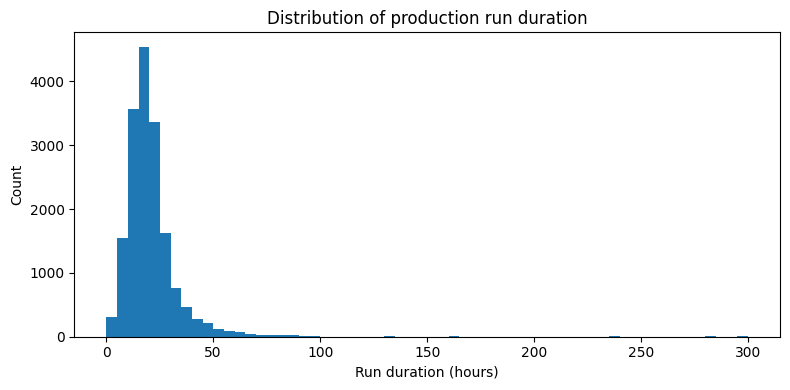

In [59]:
print(run_base["duration_min"].describe())
print(f"\n中位數：{run_base['duration_min'].median()/60:.1f} 小時")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(run_base["duration_min"] / 60, bins=60)
ax.set_xlabel("Run duration (hours)")
ax.set_ylabel("Count")
ax.set_title("Distribution of production run duration")
plt.tight_layout()
plt.show()

In [60]:
all_events = sorted(df["eventmessage"].dropna().unique().tolist())
print(f"共 {len(all_events)} 種事件類型")

event_long = (
    df.dropna(subset=["eventmessage"])
      .groupby(run_keys + ["eventmessage"], as_index=False, dropna=False)
      .agg(event_count=("eventcount", "sum"))
)

event_wide = (
    event_long
    .pivot_table(index=run_keys, columns="eventmessage",
                 values="event_count", aggfunc="sum", fill_value=0)
    .reset_index()
)

run_full = run_base.merge(event_wide, on=run_keys, how="left")
run_full[all_events] = run_full[all_events].fillna(0)

n_before = len(run_full)
run_full = run_full[run_full["in_qty"] > 0].copy()
print(f"排除 in_qty = 0：{n_before - len(run_full)} 列，剩餘 {len(run_full):,} 列")

for ev in all_events:
    run_full[f"has__{ev}"] = (run_full[ev] > 0).astype(int)

print(f"\n寬表維度：{run_full.shape}")
run_full[["equip_id", "recipe_id", "in_qty", "ng_qty", "ng_rate"] + all_events[:3]].head()

共 39 種事件類型
排除 in_qty = 0：0 列，剩餘 17,179 列

寬表維度：(17179, 93)


,equip_id,recipe_id,in_qty,ng_qty,ng_rate,1st bond point bold level error,1st bond point bond level error,2nd bond point bold level error
0,WB2061,SMIM416GG410-00-PO-00,1258,0.000000,0.000000,0.0,0.0,0.0
1,WB2061,SMIM416GG410-00-PO-00,1260,1.000000,0.000794,0.0,0.0,0.0
2,WB2061,SMIM416GG410-00-PO-00,1260,0.333333,0.000265,0.0,0.0,0.0
3,WB2061,SMIM416GG410-00-PO-00,1198,0.000000,0.000000,0.0,0.0,0.0
4,WB2062,SMIM622GN303-02-MP-00,2720,0.000000,0.000000,0.0,0.0,0.0


has 開頭欄位代表是否有該事件發生，為0,1

In [61]:
# run_full.columns

In [64]:
# run_full['AUTO-VLL-FIND-FAIL']

統計每種事件在多少個RUN裡出現過，因為數量太少的事件做不出可信的檢定

In [65]:
MIN_POS = 30   # 至少要有這麼多 run 發生過才納入分析

coverage = pd.DataFrame({
    "eventmessage": all_events,
    "total_count":  [run_full[e].sum() for e in all_events],
    "n_pos_runs":   [int(run_full[f"has__{e}"].sum()) for e in all_events],
})
coverage["pos_ratio"] = coverage["n_pos_runs"] / len(run_full)
coverage = coverage.sort_values("total_count", ascending=False).reset_index(drop=True)

analyzable = coverage.loc[coverage.n_pos_runs >= MIN_POS, "eventmessage"].tolist()
print(f"可分析事件數（n_pos >= {MIN_POS}）：{len(analyzable)} / {len(all_events)}")
coverage.head(20)

可分析事件數（n_pos >= 30）：29 / 39


,eventmessage,total_count,n_pos_runs,pos_ratio
0,PDT-UNEXPECTED-SHTL,13764.0,5217,0.303685
1,PDT-UNEXPECTED-NSOP,10216.0,4153,0.241749
2,PBI-WIRE-STOP-ERR,7433.0,2593,0.150940
3,PDT-UNEXPECTED-NSOL,5065.0,2146,0.124920
4,PDT-EFO-OPEN,3931.0,1675,0.097503
5,Ball position error,3921.0,1617,0.094127
6,No tail error,3680.0,1342,0.078119
7,Pad nonsticking error,3666.0,1668,0.097095
8,PDT-WIREFEED-ERROR,3508.0,2162,0.125851
9,Lead nonsticking error,3383.0,1696,0.098725


逐事件關聯檢定
對每一種事件，比較「有跳」vs「沒跳」的 run，`ng_rate` 分布是否有差。
用 **Mann-Whitney U**（無母數，不假設常態——報廢率分布通常極度右偏）。


In [68]:
def cliffs_delta_from_u(u_stat, n1, n2):
    # 由 Mann-Whitney U 換算 Cliff's delta，範圍 -1 ~ 1
    return 2.0 * u_stat / (n1 * n2) - 1.0


records = []

for ev in analyzable:
    flag = run_full[f"has__{ev}"]
    a = run_full.loc[flag == 1, "ng_rate"].dropna()
    b = run_full.loc[flag == 0, "ng_rate"].dropna()

    if len(a) < MIN_POS or len(b) < MIN_POS:
        continue

    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    delta = cliffs_delta_from_u(u, len(a), len(b))

    records.append({
        "eventmessage":     ev,
        "n_pos":            len(a),
        "n_neg":            len(b),
        "median_ng_rate_pos": a.median(),
        "median_ng_rate_neg": b.median(),
        "diff_pp":          (a.median() - b.median()) * 100,   # 百分點
        "cliffs_delta":     delta,
        "p_raw":            p,
    })

assoc = pd.DataFrame(records).sort_values("cliffs_delta", ascending=False)
print(f"完成 {len(assoc)} 個檢定")
assoc.head(15)

完成 29 個檢定


,eventmessage,n_pos,n_neg,median_ng_rate_pos,median_ng_rate_neg,diff_pp,cliffs_delta,p_raw
21,WIRE-INSP-WIRE-STOP-ERR,61,17118,0.000478,0.0,0.047824,0.537649,2.803201e-18
25,Pad nonsticking Standard Value error,53,17126,0.000358,0.0,0.035765,0.498282,4.921489e-14
20,PDT-NO-FS-DETECT,157,17022,0.000180,0.0,0.017986,0.305662,2.189291e-15
18,PDT-UNEXPECTED-LGTL,123,17056,0.000160,0.0,0.016026,0.282813,7.983678e-11
13,No bump tail error,694,16485,0.000178,0.0,0.017803,0.256044,5.509520e-43
3,PDT-UNEXPECTED-NSOL,2146,15033,0.000140,0.0,0.014006,0.244811,6.489967e-108
17,BI wire curl error,355,16824,0.000149,0.0,0.014881,0.229796,4.984611e-19
14,Ball size error,630,16549,0.000094,0.0,0.009444,0.198226,3.058729e-24
4,PDT-EFO-OPEN,1675,15504,0.000000,0.0,0.000000,0.186954,1.197307e-51
28,PDT-BONDHEIGHT-ERROR,31,17148,0.000130,0.0,0.012960,0.164866,5.643630e-02


多重比較校正。用 **Benjamini-Hochberg** 控制偽發現率。輸出會同時印出「校正前顯著幾個、校正後幾個」——這個對比本身就說明了為什麼要做校正。

In [69]:
reject, p_adj, _, _ = multipletests(assoc["p_raw"].values, alpha=0.05, method="fdr_bh")
assoc["p_bh"] = p_adj
assoc["sig_bh"] = reject

print(f"BH 校正後顯著的事件數：{assoc.sig_bh.sum()} / {len(assoc)}")
print(f"（若不校正，p_raw < 0.05 的有 {(assoc.p_raw < 0.05).sum()} 個）")

assoc[["eventmessage", "n_pos", "diff_pp", "cliffs_delta", "p_raw", "p_bh", "sig_bh"]].head(20)

BH 校正後顯著的事件數：22 / 29
（若不校正，p_raw < 0.05 的有 22 個）


,eventmessage,n_pos,diff_pp,cliffs_delta,p_raw,p_bh,sig_bh
21,WIRE-INSP-WIRE-STOP-ERR,61,0.047824,0.537649,2.803201e-18,7.390256e-18,True
25,Pad nonsticking Standard Value error,53,0.035765,0.498282,4.921489e-14,1.019451e-13,True
20,PDT-NO-FS-DETECT,157,0.017986,0.305662,2.189291e-15,4.883804e-15,True
18,PDT-UNEXPECTED-LGTL,123,0.016026,0.282813,7.983678e-11,1.447042e-10,True
13,No bump tail error,694,0.017803,0.256044,5.509520e-43,3.994402e-42,True
3,PDT-UNEXPECTED-NSOL,2146,0.014006,0.244811,6.489967e-108,1.882091e-106,True
17,BI wire curl error,355,0.014881,0.229796,4.984611e-19,1.445537e-18,True
14,Ball size error,630,0.009444,0.198226,3.058729e-24,1.478386e-23,True
4,PDT-EFO-OPEN,1675,0.000000,0.186954,1.197307e-51,1.157397e-50,True
28,PDT-BONDHEIGHT-ERROR,31,0.012960,0.164866,5.643630e-02,7.115881e-02,False


In [70]:
MIN_RUNS_PER_RECIPE = 20   # 配方至少要有這麼多 run 才納入（控制 dummy 數量）

recipe_n = run_full["recipe_id"].value_counts()
keep_recipes = recipe_n[recipe_n >= MIN_RUNS_PER_RECIPE].index
model_df = run_full[run_full["recipe_id"].isin(keep_recipes)].copy()

print(f"保留配方數：{len(keep_recipes)} / {run_full.recipe_id.nunique()}")
print(f"保留 run 數：{len(model_df):,} / {len(run_full):,} "
      f"({len(model_df)/len(run_full):.1%})")

model_df["log_in_qty"] = np.log(model_df["in_qty"])

保留配方數：163 / 305
保留 run 數：16,133 / 17,179 (93.9%)


In [71]:
def fit_event_effect(data, ev, min_pos=MIN_POS):
    # 對單一事件配適 Poisson GLM（含 recipe 固定效應）
    # 回傳發生率比、信賴區間，以及以反事實預測估算的期望額外報廢量
    d = data.copy()
    d["has_event"] = d[f"has__{ev}"]
    d["ev_count"]  = d[ev]

    if int(d["has_event"].sum()) < min_pos:
        return None

    # 只保留同時有正負樣本的配方，否則該配方 dummy 與 has_event 完全共線
    ok = (d.groupby("recipe_id")["has_event"]
            .agg(["mean", "size"])
            .query("0 < mean < 1")
            .index)
    d = d[d["recipe_id"].isin(ok)]
    if d.empty or d["has_event"].sum() < min_pos:
        return None

    try:
        res = smf.glm(
            "ng_qty ~ has_event + C(recipe_id)",
            data=d,
            family=sm.families.Poisson(),
            offset=d["log_in_qty"],
        ).fit(cov_type="cluster", cov_kwds={"groups": d["equip_id"]})
    except Exception as e:
        print(f"  [skip] {ev}: {e}")
        return None

    beta = res.params.get("has_event", np.nan)
    se   = res.bse.get("has_event", np.nan)
    pval = res.pvalues.get("has_event", np.nan)

    # 反事實預測：把有事件的 run 假設成沒事件，看報廢量差多少
    pos = d[d["has_event"] == 1].copy()
    pred_with = res.predict(pos, offset=pos["log_in_qty"])
    pos0 = pos.copy()
    pos0["has_event"] = 0
    pred_without = res.predict(pos0, offset=pos0["log_in_qty"])

    excess_total = float((pred_with - pred_without).sum())
    n_occurrence = float(pos["ev_count"].sum())

    return {
        "eventmessage":    ev,
        "n_pos_runs":      int(pos.shape[0]),
        "n_occurrence":    n_occurrence,
        "rate_ratio":      float(np.exp(beta)),
        "rr_lo":           float(np.exp(beta - 1.96 * se)),
        "rr_hi":           float(np.exp(beta + 1.96 * se)),
        "p_adj_model":     float(pval),
        "excess_ng_total": excess_total,
        "excess_per_occ":  excess_total / n_occurrence if n_occurrence > 0 else np.nan,
    }


results = []
for i, ev in enumerate(analyzable, 1):
    print(f"[{i}/{len(analyzable)}] {ev}")
    r = fit_event_effect(model_df, ev)
    if r is not None:
        results.append(r)

glm_res = pd.DataFrame(results)
print(f"\n成功配適 {len(glm_res)} 個事件")

[1/29] PDT-UNEXPECTED-SHTL
[2/29] PDT-UNEXPECTED-NSOP
[3/29] PBI-WIRE-STOP-ERR
[4/29] PDT-UNEXPECTED-NSOL
[5/29] PDT-EFO-OPEN
[6/29] Ball position error
[7/29] No tail error
[8/29] Pad nonsticking error
[9/29] PDT-WIREFEED-ERROR
[10/29] Lead nonsticking error
[11/29] EFU open error
[12/29] EH-PDT-SMBALL
[13/29] Spool empty error
[14/29] No bump tail error
[15/29] Ball size error
[16/29] AUTO-VLL-FIND-FAIL
[17/29] BI ball existence error
[18/29] BI wire curl error
[19/29] PDT-UNEXPECTED-LGTL
[20/29] Lead locating detection error
[21/29] PDT-NO-FS-DETECT
[22/29] WIRE-INSP-WIRE-STOP-ERR
[23/29] US frequency error
[24/29] PDT-EFO-SHORT
[25/29] AUTO-USG-IMPEDANCE-OUT-LIMIT
[26/29] Pad nonsticking Standard Value error
[27/29] EFU short error
[28/29] RPS Y offset outlying ERR-Stop
[29/29] PDT-BONDHEIGHT-ERROR

成功配適 27 個事件


In [72]:
if len(glm_res) > 0:
    rej, padj, _, _ = multipletests(glm_res["p_adj_model"].values,
                                    alpha=0.05, method="fdr_bh")
    glm_res["p_bh"] = padj
    glm_res["sig"] = rej

glm_res = glm_res.sort_values("rate_ratio", ascending=False)
glm_res[["eventmessage", "n_pos_runs", "rate_ratio", "rr_lo", "rr_hi",
         "p_bh", "sig", "excess_per_occ"]].head(20)

,eventmessage,n_pos_runs,rate_ratio,rr_lo,rr_hi,p_bh,sig,excess_per_occ
4,PDT-EFO-OPEN,1566,3.319614,1.620135,6.801803,0.005638,True,1.045909
3,PDT-UNEXPECTED-NSOL,2016,3.215947,1.572295,6.577845,0.005808,True,0.836634
20,PDT-NO-FS-DETECT,150,2.575632,0.715347,9.273648,0.199478,False,3.263861
0,PDT-UNEXPECTED-SHTL,4977,2.296522,1.080482,4.881166,0.051770,False,0.238329
7,Pad nonsticking error,1487,1.645371,1.368474,1.978294,0.000002,True,0.066637
19,Lead locating detection error,189,1.618392,0.993633,2.635975,0.079607,False,0.176182
9,Lead nonsticking error,1548,1.587418,1.337138,1.884545,0.000002,True,0.087987
15,AUTO-VLL-FIND-FAIL,658,1.567180,0.386591,6.353105,0.638516,False,0.248778
16,BI ball existence error,492,1.529066,1.090718,2.143580,0.028551,True,0.095269
13,No bump tail error,635,1.510421,1.200371,1.900555,0.003914,True,0.090147


In [73]:
compare = (assoc[["eventmessage", "cliffs_delta", "diff_pp", "sig_bh"]]
           .merge(glm_res[["eventmessage", "rate_ratio", "rr_lo", "rr_hi", "sig"]],
                  on="eventmessage", how="inner")
           .rename(columns={"sig_bh": "sig_before", "sig": "sig_after"}))

compare["confounded"] = compare["sig_before"] & (~compare["sig_after"])
print(f"控制配方後失去顯著性的事件數：{compare.confounded.sum()}")
compare.sort_values("rate_ratio", ascending=False).head(20)

控制配方後失去顯著性的事件數：9


,eventmessage,cliffs_delta,diff_pp,sig_before,rate_ratio,rr_lo,rr_hi,sig_after,confounded
8,PDT-EFO-OPEN,0.186954,0.000000,True,3.319614,1.620135,6.801803,True,False
5,PDT-UNEXPECTED-NSOL,0.244811,0.014006,True,3.215947,1.572295,6.577845,True,False
2,PDT-NO-FS-DETECT,0.305662,0.017986,True,2.575632,0.715347,9.273648,False,True
15,PDT-UNEXPECTED-SHTL,0.105165,0.000000,True,2.296522,1.080482,4.881166,False,True
16,Pad nonsticking error,0.103643,0.000000,True,1.645371,1.368474,1.978294,True,False
19,Lead locating detection error,0.042684,0.000000,False,1.618392,0.993633,2.635975,False,False
11,Lead nonsticking error,0.122446,0.000000,True,1.587418,1.337138,1.884545,True,False
14,AUTO-VLL-FIND-FAIL,0.106755,0.000000,True,1.567180,0.386591,6.353105,False,True
12,BI ball existence error,0.121361,0.000000,True,1.529066,1.090718,2.143580,True,False
4,No bump tail error,0.256044,0.017803,True,1.510421,1.200371,1.900555,True,False


In [74]:
def dose_response(data, ev, bins=(0, 1, 2, 4, 10, np.inf)):
    # 依事件次數分箱，檢視 ng_rate 是否單調上升
    d = data[["ng_rate", ev]].dropna().copy()
    labels = ["0", "1", "2-3", "4-9", "10+"]
    d["bin"] = pd.cut(d[ev], bins=bins, labels=labels, right=False)

    summary = (d.groupby("bin", observed=True)
                 .agg(n=("ng_rate", "size"),
                      mean_ng_rate=("ng_rate", "mean"),
                      median_ng_rate=("ng_rate", "median"))
                 .reset_index())

    # 只在有發生事件的 run 上做趨勢檢定，避免 0 這一大群主導結果
    pos = d[d[ev] > 0]
    if len(pos) >= MIN_POS:
        rho, p = stats.spearmanr(pos[ev], pos["ng_rate"])
    else:
        rho, p = np.nan, np.nan

    return summary, rho, p


top_events = glm_res.loc[glm_res.get("sig", True), "eventmessage"].head(5).tolist()
if not top_events:
    top_events = glm_res["eventmessage"].head(5).tolist()

for ev in top_events:
    summary, rho, p = dose_response(run_full, ev)
    print(f"\n=== {ev} ===")
    print(summary.to_string(index=False))
    print(f"Spearman（僅正樣本）: rho = {rho:.3f}, p = {p:.4g}")


=== PDT-EFO-OPEN ===
bin     n  mean_ng_rate  median_ng_rate
  0 15504      0.000385        0.000000
  1   984      0.000677        0.000000
2-3   441      0.002392        0.000129
4-9   199      0.002207        0.000178
10+    51      0.010207        0.000847
Spearman（僅正樣本）: rho = 0.153, p = 3.445e-10

=== PDT-UNEXPECTED-NSOL ===
bin     n  mean_ng_rate  median_ng_rate
  0 15033      0.000375        0.000000
  1  1275      0.000536        0.000000
2-3   592      0.000477        0.000210
4-9   214      0.000833        0.000402
10+    65      0.028696        0.000909
Spearman（僅正樣本）: rho = 0.227, p = 1.778e-26

=== Pad nonsticking error ===
bin     n  mean_ng_rate  median_ng_rate
  0 15511      0.000522        0.000000
  1   926      0.000230        0.000000
2-3   514      0.000353        0.000000
4-9   189      0.000592        0.000176
10+    39      0.001252        0.000485
Spearman（僅正樣本）: rho = 0.196, p = 7.741e-16

=== Lead nonsticking error ===
bin     n  mean_ng_rate  median_ng_ra

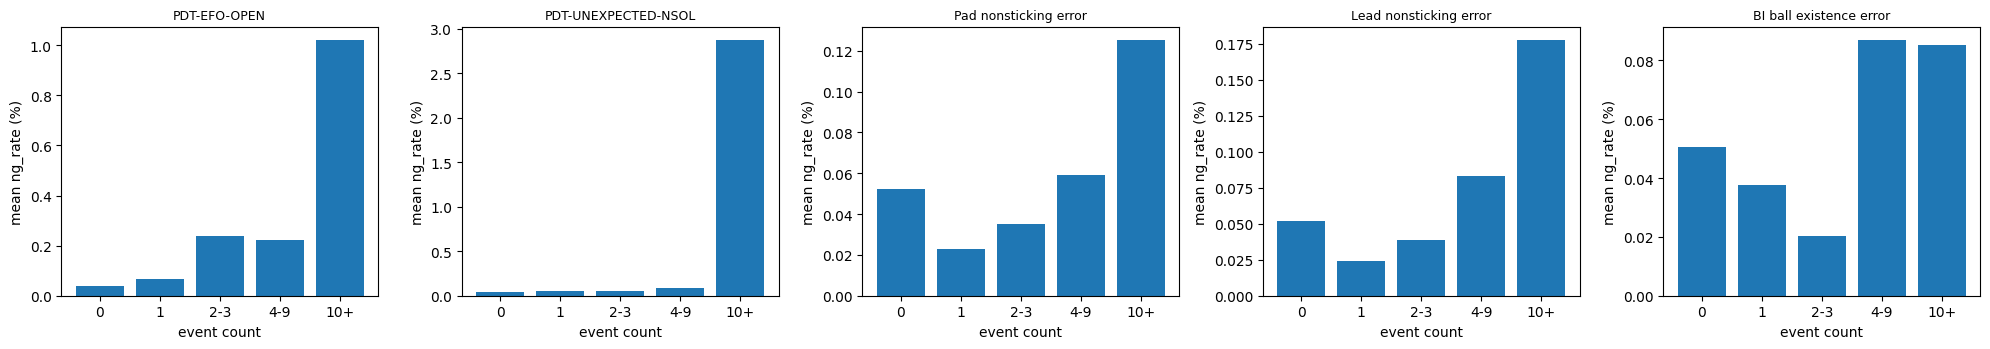

In [75]:
n = len(top_events)
if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.6), squeeze=False)
    for ax, ev in zip(axes[0], top_events):
        summary, rho, p = dose_response(run_full, ev)
        ax.bar(summary["bin"].astype(str), summary["mean_ng_rate"] * 100)
        ax.set_title(ev[:28], fontsize=9)
        ax.set_xlabel("event count")
        ax.set_ylabel("mean ng_rate (%)")
    plt.tight_layout()
    plt.show()

In [76]:
UNIT_COST = None   # 若知道單顆成本（元/顆），填在這裡

cost_table = (glm_res
    .merge(coverage[["eventmessage", "total_count"]], on="eventmessage", how="left")
    .assign(weekly_excess_ng=lambda x: x["excess_per_occ"] * x["total_count"])
    .sort_values("weekly_excess_ng", ascending=False)
)

cols = ["eventmessage", "total_count", "n_pos_runs",
        "rate_ratio", "rr_lo", "rr_hi",
        "excess_per_occ", "weekly_excess_ng", "p_bh", "sig"]
cost_table = cost_table[[c for c in cols if c in cost_table.columns]]

if UNIT_COST is not None:
    cost_table["weekly_cost"] = cost_table["weekly_excess_ng"] * UNIT_COST

print("=== 依期望報廢量排序 ===")
display(cost_table.head(20).round(4))

=== 依期望報廢量排序 ===


,eventmessage,total_count,n_pos_runs,rate_ratio,rr_lo,rr_hi,excess_per_occ,weekly_excess_ng,p_bh,sig
1,PDT-UNEXPECTED-NSOL,5065.0,2016,3.2159,1.5723,6.5778,0.8366,4237.5526,0.0058,True
0,PDT-EFO-OPEN,3931.0,1566,3.3196,1.6201,6.8018,1.0459,4111.4670,0.0056,True
3,PDT-UNEXPECTED-SHTL,13764.0,4977,2.2965,1.0805,4.8812,0.2383,3280.3585,0.0518,False
2,PDT-NO-FS-DETECT,200.0,150,2.5756,0.7153,9.2736,3.2639,652.7721,0.1995,False
6,Lead nonsticking error,3383.0,1548,1.5874,1.3371,1.8845,0.0880,297.6589,0.0000,True
7,AUTO-VLL-FIND-FAIL,1133.0,658,1.5672,0.3866,6.3531,0.2488,281.8649,0.6385,False
18,PDT-UNEXPECTED-NSOP,10216.0,3946,1.0703,0.5355,2.1393,0.0261,266.7604,0.9074,False
4,Pad nonsticking error,3666.0,1487,1.6454,1.3685,1.9783,0.0666,244.2896,0.0000,True
9,No bump tail error,1556.0,635,1.5104,1.2004,1.9006,0.0901,140.2693,0.0039,True
12,Spool empty error,1577.0,876,1.4453,1.1718,1.7828,0.0678,106.9772,0.0039,True


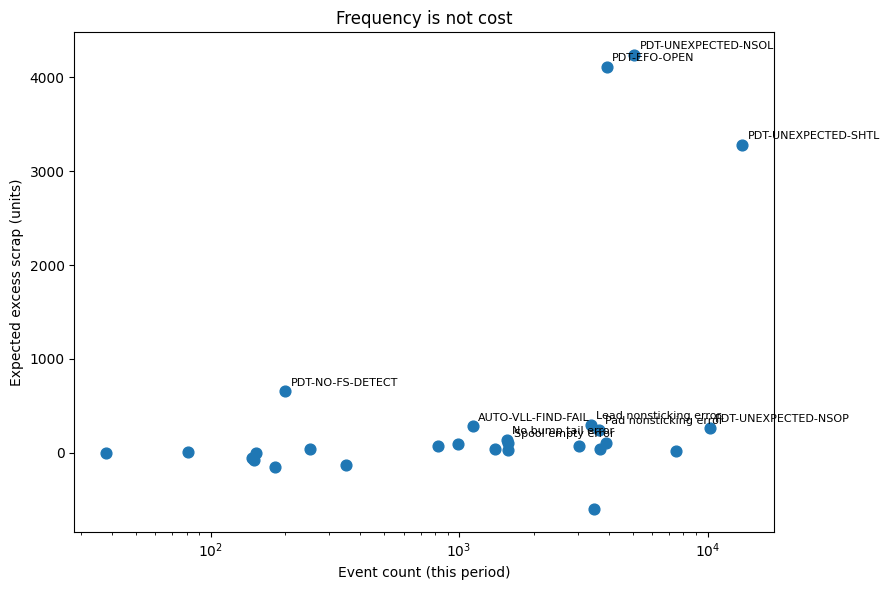

In [77]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(cost_table["total_count"], cost_table["weekly_excess_ng"], s=60)

for _, r in cost_table.head(10).iterrows():
    ax.annotate(r["eventmessage"][:22],
                (r["total_count"], r["weekly_excess_ng"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("Event count (this period)")
ax.set_ylabel("Expected excess scrap (units)")
ax.set_title("Frequency is not cost")
ax.set_xscale("log")
plt.tight_layout()
plt.show()